# 22 — Gateway Decision Analysis (Camargo Helpdesk)

For each gateway (activity with >1 observed successor), train:

1. **LSTM Surrogate** — target = Camargo's predicted next activity.
2. **Ground Truth** — target = actual next activity from the event log.

Same stratified 60/20/20 split, same C4.5 classifier and depth sweep as the henryk notebook, but with predictions coming from the Camargo `FullShared_Join_LSTM`.

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

from src.interpretability.surrogate.c45_tree import C45Classifier

SPEC = utils.HELPDESK
model = utils.load_camargo_model(_current, SPEC)
dataset = utils.load_test_dataset(_current, SPEC)
window = utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
eos_idx = predictor.eos_idx
idx_to_name = predictor.idx_to_name
ACT_IDX = SPEC.cat_indices[0]  # position of Activity/concept:name in henryk cats
RES_IDX = SPEC.cat_indices[1]  # Resource/org:resource
CET_IDX = SPEC.num_indices[0]  # case_elapsed_time
print(f'{SPEC.name} | window={window} | vocab={predictor.n_classes}')

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {})])
Model input features:  [['Activity', 'Resource'], ['case_elapsed_time']]


Embeddings:  ModuleList(
  (0): Embedding(16, 8)
  (1): Embedding(24, 9)
)
Total embedding feature size:  17
Input feature size:  18
Cells hidden size:  50
Number of LSTM layer:  1


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Helpdesk | window=13 | vocab=16


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

## Build DFG and identify qualifying gateways

In [2]:
MIN_CASES = 20
MIN_BRANCH = 1
MIN_SAMPLES_LEAF = 20
ACTIVITY_WINDOW = 10  # positional history depth

# Unique cases (longest trace per case_id)
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)
print(f'{len(cases)} unique cases')

# DFG over ground-truth transitions
dfg = {}
for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    acts = cat_full[ACT_IDX].tolist()
    nonzero = [i for i, a in enumerate(acts) if a != 0]
    if not nonzero:
        continue
    start = nonzero[0]
    useful_len = len(nonzero)
    while useful_len > 0 and acts[start + useful_len - 1] == eos_idx:
        useful_len -= 1
    names = [idx_to_name.get(acts[start + k]) for k in range(useful_len)]
    for k in range(len(names) - 1):
        edge = (names[k], names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

successors_map = {}
for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {act: succs for act, succs in successors_map.items() if len(succs) > 1}
print(f'{len(decision_points)} gateways')
for act, succs in sorted(decision_points.items(), key=lambda x: -sum(x[1].values())):
    total = sum(succs.values())
    branches = ', '.join(f'{s} ({c})' for s, c in sorted(succs.items(), key=lambda x: -x[1]))
    print(f'  {act} ({total}): {branches}')

916 unique cases
9 gateways
  Take in charge ticket (996): Resolve ticket (717), Wait (243), Take in charge ticket (16), Require upgrade (12), Create SW anomaly (7), Schedule intervention (1)
  Assign seriousness (995): Take in charge ticket (837), Assign seriousness (96), Resolve ticket (50), Wait (11), Require upgrade (1)
  Resolve ticket (987): Closed (910), Resolve ticket (50), Take in charge ticket (26), RESOLVED (1)
  Wait (279): Resolve ticket (153), Take in charge ticket (99), Wait (24), Require upgrade (1), Create SW anomaly (1), Assign seriousness (1)
  Insert ticket (28): Assign seriousness (26), Wait (2)
  Require upgrade (20): Resolve ticket (9), Require upgrade (4), Wait (3), Create SW anomaly (3), Take in charge ticket (1)
  Create SW anomaly (12): Resolve ticket (8), Require upgrade (2), Create SW anomaly (1), Resolve SW anomaly (1)
  Closed (6): Closed (5), Take in charge ticket (1)
  Resolve SW anomaly (2): Resolve SW anomaly (1), Require upgrade (1)


## Collect per-gateway prefixes + LSTM predictions

In [3]:
def extract_features(acts_history, res_history, cet_history, prefix_len):
    """Positional categorical features for the last ACTIVITY_WINDOW events plus prefix_length."""
    feats = {'prefix_length': prefix_len}
    for w in range(1, ACTIVITY_WINDOW + 1):
        pos = prefix_len - w
        feats[f'activity_pos_{-w}'] = idx_to_name.get(acts_history[pos]) if pos >= 0 else '<pad>'
        feats[f'resource_pos_{-w}'] = int(res_history[pos]) if pos >= 0 else -1
        feats[f'cet_pos_{-w}'] = float(cet_history[pos]) if pos >= 0 else float('nan')
    return feats


gateway_data = {}
for gateway_act, succs in decision_points.items():
    qualifying = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying) < 2 or sum(succs.values()) < MIN_CASES:
        continue

    rows_X, y_actual, y_lstm = [], [], []
    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        acts_raw = cat_full[ACT_IDX].tolist()
        nonzero = [i for i, a in enumerate(acts_raw) if a != 0]
        if not nonzero:
            continue
        start = nonzero[0]
        useful_len = len(nonzero)
        while useful_len > 0 and acts_raw[start + useful_len - 1] == eos_idx:
            useful_len -= 1

        for k in range(useful_len - 1):
            if idx_to_name.get(acts_raw[start + k]) != gateway_act:
                continue
            prefix_len = k + 1
            # actual next
            next_name = idx_to_name.get(acts_raw[start + prefix_len])
            # build prefix window for LSTM
            cats_win, nums_win = utils.make_prefix_window(
                cat_full, num_full, start=start, prefix_length=prefix_len,
                window=window, spec=SPEC,
            )
            pred_idx, _ = predictor.predict_batch(cats_win, nums_win)
            pred_name = idx_to_name.get(int(pred_idx.item()), f'<{int(pred_idx.item())}>')
            # feature row
            acts_history = [acts_raw[start + j] for j in range(prefix_len)]
            res_history = cat_full[RES_IDX].tolist()
            res_history = [res_history[start + j] for j in range(prefix_len)]
            cet_history = num_full[CET_IDX].tolist()
            cet_history = [cet_history[start + j] for j in range(prefix_len)]
            rows_X.append(extract_features(acts_history, res_history, cet_history, prefix_len))
            y_actual.append(next_name)
            y_lstm.append(pred_name)

    if len(rows_X) < MIN_CASES:
        continue

    X = pd.DataFrame(rows_X)
    y_actual = np.array(y_actual)
    y_lstm = np.array(y_lstm)
    lstm_acc = float((y_lstm == y_actual).mean())
    print(f'{gateway_act}: N={len(X)}, LSTM acc={lstm_acc:.3f}, actual branches={len(set(y_actual))}, LSTM branches={len(set(y_lstm))}')
    gateway_data[gateway_act] = {'X': X, 'y_actual': y_actual, 'y_lstm': y_lstm, 'successors': succs}

print(f'\n{len(gateway_data)} qualifying gateways: {list(gateway_data.keys())}')

Assign seriousness: N=995, LSTM acc=0.029, actual branches=5, LSTM branches=2


Take in charge ticket: N=996, LSTM acc=0.719, actual branches=6, LSTM branches=2


Resolve ticket: N=987, LSTM acc=0.921, actual branches=4, LSTM branches=2


Wait: N=279, LSTM acc=0.548, actual branches=6, LSTM branches=1
Insert ticket: N=28, LSTM acc=0.000, actual branches=2, LSTM branches=1
Require upgrade: N=20, LSTM acc=0.400, actual branches=5, LSTM branches=2

6 qualifying gateways: ['Assign seriousness', 'Take in charge ticket', 'Resolve ticket', 'Wait', 'Insert ticket', 'Require upgrade']


## Train surrogate + ground-truth trees per gateway

In [ ]:
def select_depth(X_tr, y_tr, X_val, y_val, cat_feats, depths=(3, 4, 5, 6, 7, 8)):
    best = None
    for d in depths:
        clf = C45Classifier(max_depth=d, min_samples_leaf=MIN_SAMPLES_LEAF, class_weight='balanced', random_state=42)
        clf.fit(X_tr, y_tr, categorical_features=cat_feats)
        val = clf.score(X_val, y_val)
        if best is None or val > best['val'] + 0.02:
            best = {'depth': d, 'val': val, 'clf': clf}
    return best['clf']


gateway_results = {}
for gw, gd in gateway_data.items():
    X, y_actual, y_lstm = gd['X'], gd['y_actual'], gd['y_lstm']
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']

    try:
        X_tv, X_te, y_lstm_tv, y_lstm_te, y_act_tv, y_act_te = train_test_split(
            X, y_lstm, y_actual, test_size=0.2, random_state=42, stratify=y_actual)
    except ValueError:
        X_tv, X_te, y_lstm_tv, y_lstm_te, y_act_tv, y_act_te = train_test_split(
            X, y_lstm, y_actual, test_size=0.2, random_state=42)
    try:
        X_tr, X_val, y_lstm_tr, y_lstm_val, y_act_tr, y_act_val = train_test_split(
            X_tv, y_lstm_tv, y_act_tv, test_size=0.25, random_state=42, stratify=y_act_tv)
    except ValueError:
        X_tr, X_val, y_lstm_tr, y_lstm_val, y_act_tr, y_act_val = train_test_split(
            X_tv, y_lstm_tv, y_act_tv, test_size=0.25, random_state=42)

    clf_lstm = select_depth(X_tr, y_lstm_tr, X_val, y_lstm_val, cat_cols)
    clf_gt = select_depth(X_tr, y_act_tr, X_val, y_act_val, cat_cols)
    fidelity = clf_lstm.score(X_te, y_lstm_te)
    gt_acc = clf_gt.score(X_te, y_act_te)
    lstm_acc = float((y_lstm_te == y_act_te).mean())
    agree = float((clf_lstm.predict(X_te) == clf_gt.predict(X_te)).mean())

    gateway_results[gw] = {'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
                           'fidelity': fidelity, 'gt_acc': gt_acc,
                           'lstm_acc': lstm_acc, 'agreement': agree,
                           'X_test': X_te, 'y_lstm_test': y_lstm_te, 'y_actual_test': y_act_te,
                           'n_cases': len(X)}
    print(f'{gw}: N={len(X)} | LSTM acc={lstm_acc:.3f} | fidelity={fidelity:.3f} | GT acc={gt_acc:.3f} | agree={agree:.3f}')

Assign seriousness: N=995 | LSTM acc=0.035 | fidelity=0.955 | GT acc=0.849 | agree=0.000


Take in charge ticket: N=996 | LSTM acc=0.685 | fidelity=1.000 | GT acc=0.685 | agree=1.000


Resolve ticket: N=987 | LSTM acc=0.929 | fidelity=1.000 | GT acc=0.929 | agree=1.000


Wait: N=279 | LSTM acc=0.518 | fidelity=1.000 | GT acc=0.518 | agree=1.000
Insert ticket: N=28 | LSTM acc=0.000 | fidelity=1.000 | GT acc=1.000 | agree=0.000
Require upgrade: N=20 | LSTM acc=0.750 | fidelity=1.000 | GT acc=0.750 | agree=1.000


## Readable rules

In [5]:
def print_rules(clf, label, max_rules=6):
    rules = clf.extract_rules()
    print(f'  {label} ({len(rules)} rules, showing {min(max_rules, len(rules))}):')
    for i, r in enumerate(rules[:max_rules]):
        conds = ' AND '.join(r['conditions']) if r['conditions'] else '<root>'
        print(f"    Rule {i+1} (n={r['n_samples']}, {r['confidence']:.0%}): IF {conds} THEN -> {r['prediction']}")

for gw, gr in gateway_results.items():
    print('=' * 72)
    print(f'Gateway: {gw}')
    print_rules(gr['clf_lstm'], 'LSTM Surrogate (C4.5)')
    print_rules(gr['clf_gt'], 'Ground Truth (C4.5)')

Gateway: Assign seriousness
  LSTM Surrogate (C4.5) (5 rules, showing 5):
    Rule 1 (n=276, 97%): IF resource_pos_-1 > 2.5 AND resource_pos_-1 <= 19 THEN -> Resolve ticket
    Rule 2 (n=188, 97%): IF resource_pos_-1 <= 2.5 THEN -> EOS
    Rule 3 (n=73, 96%): IF resource_pos_-1 > 2.5 AND resource_pos_-1 > 19 AND resource_pos_-1 <= 22.5 AND prefix_length <= 1.5 THEN -> EOS
    Rule 4 (n=39, 100%): IF resource_pos_-1 > 2.5 AND resource_pos_-1 > 19 AND resource_pos_-1 > 22.5 THEN -> Resolve ticket
    Rule 5 (n=21, 100%): IF resource_pos_-1 > 2.5 AND resource_pos_-1 > 19 AND resource_pos_-1 <= 22.5 AND prefix_length > 1.5 THEN -> Resolve ticket
  Ground Truth (C4.5) (1 rules, showing 1):
    Rule 1 (n=597, 84%): IF <root> THEN -> Take in charge ticket
Gateway: Take in charge ticket
  LSTM Surrogate (C4.5) (1 rules, showing 1):
    Rule 1 (n=597, 100%): IF <root> THEN -> Resolve ticket
  Ground Truth (C4.5) (1 rules, showing 1):
    Rule 1 (n=597, 73%): IF <root> THEN -> Resolve ticket
Gat

## Summary table

In [6]:
rows = []
for gw, gr in gateway_results.items():
    rows.append({'Gateway': gw, '#Cases': gr['n_cases'],
                 'LSTM Acc': gr['lstm_acc'], 'Fidelity': gr['fidelity'],
                 'GT Tree Acc': gr['gt_acc'], 'Agreement': gr['agreement']})
pd.DataFrame(rows)

,Gateway,#Cases,LSTM Acc,Fidelity,GT Tree Acc,Agreement
0,Assign seriousness,995,0.035176,0.954774,0.849246,0.0
1,Take in charge ticket,996,0.685000,1.000000,0.685000,1.0
2,Resolve ticket,987,0.929293,1.000000,0.929293,1.0
3,Wait,279,0.517857,1.000000,0.517857,1.0
4,Insert ticket,28,0.000000,1.000000,1.000000,0.0
5,Require upgrade,20,0.750000,1.000000,0.750000,1.0


## Side-by-side trees: Ground Truth vs LSTM Surrogate

For each gateway, the ground-truth decision tree (left) next to the LSTM surrogate tree (right). Orange nodes are internal splits; blue nodes are leaves showing the predicted class, sample count and confidence.

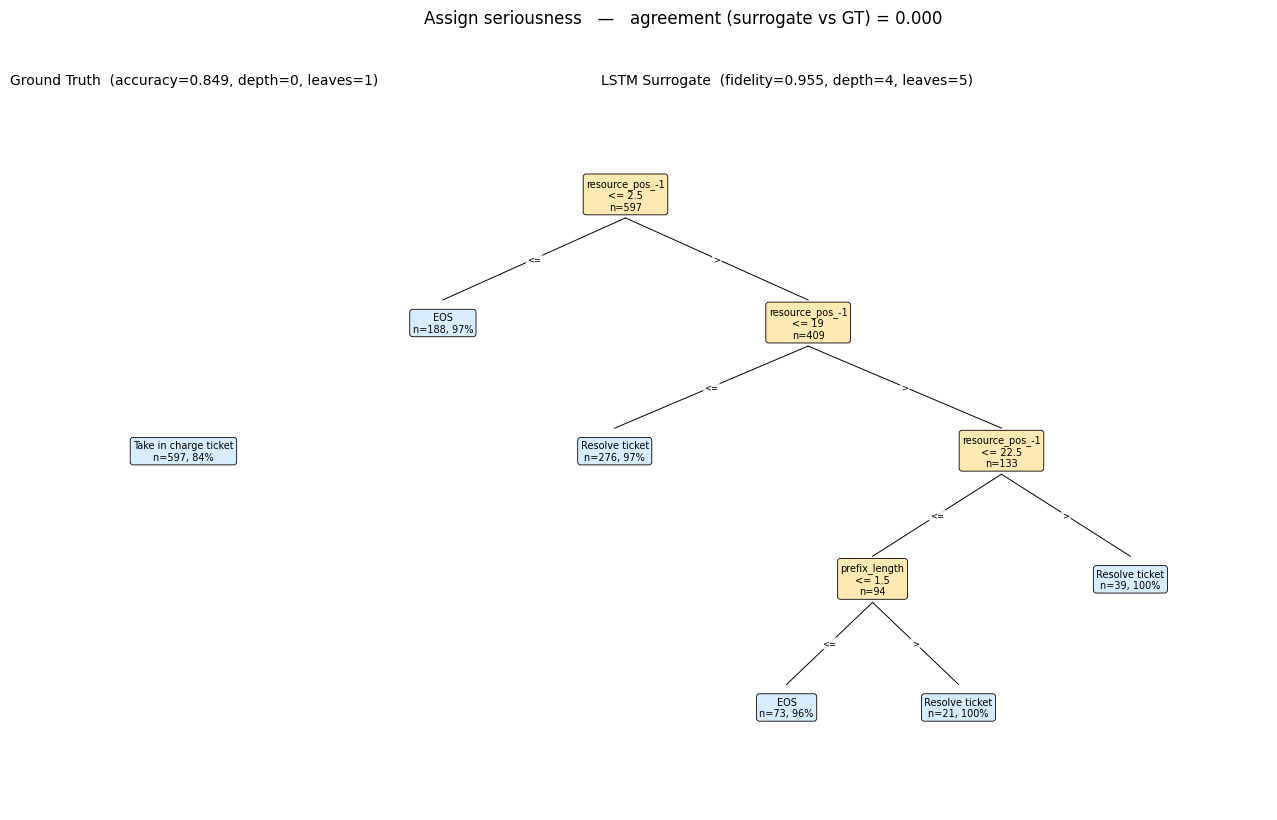

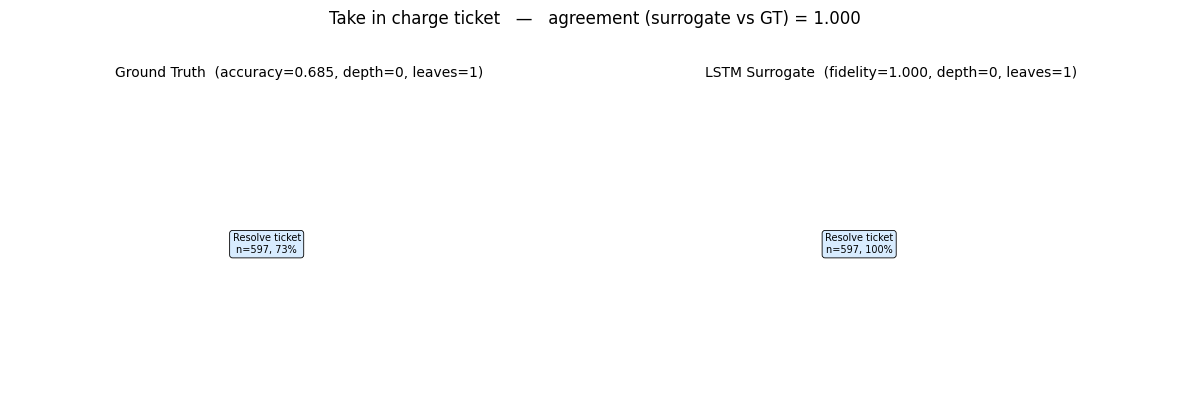

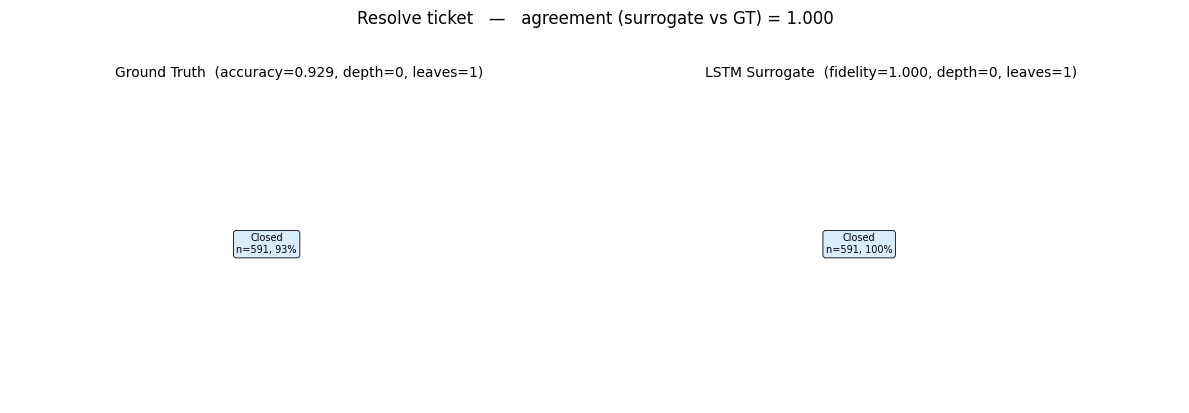

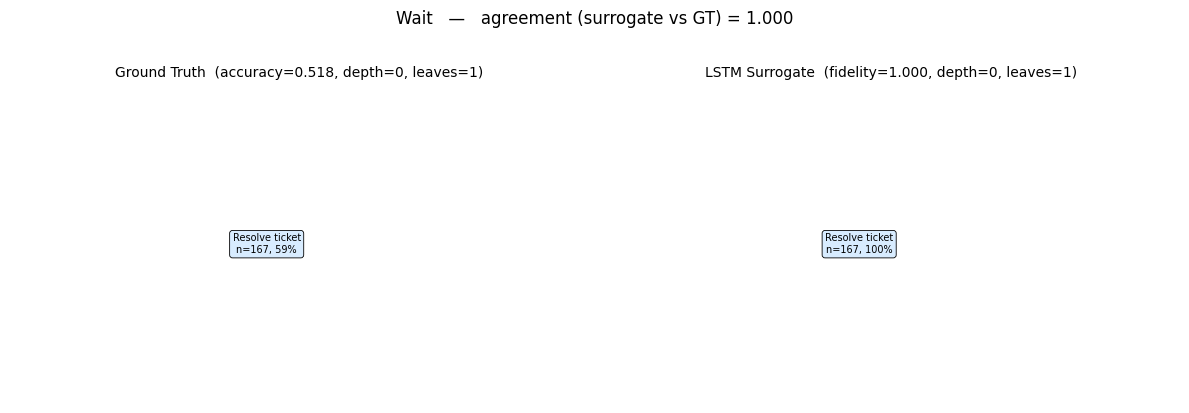

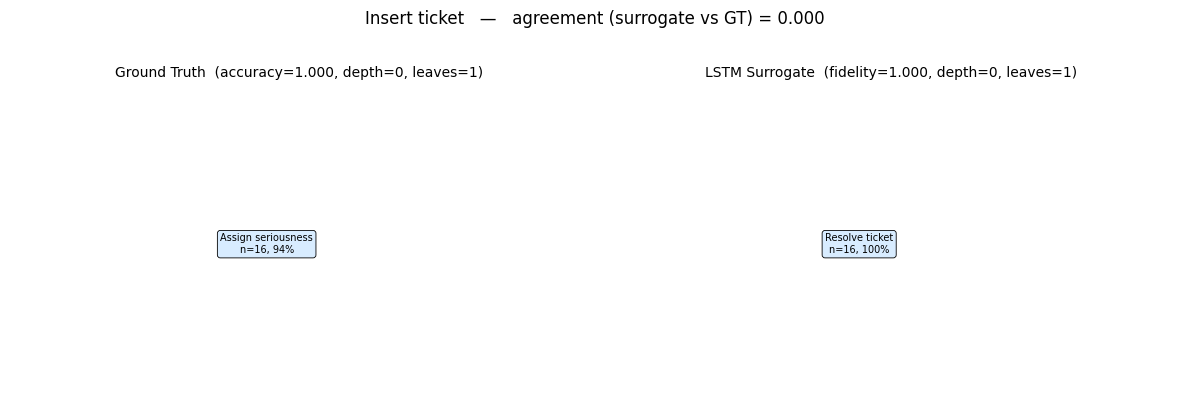

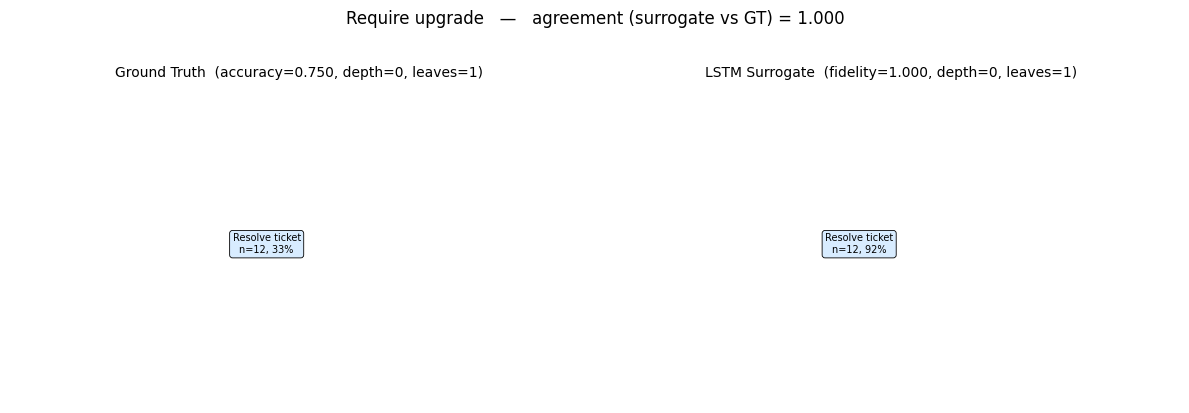

In [7]:
import matplotlib.pyplot as plt


def plot_c45_tree_ax(clf, ax, title=''):
    """Render a C4.5 tree into a given matplotlib axis. Same layout as henryk notebook 22."""
    root = clf.root_
    if root is None:
        return

    positions = {}
    leaf_counter = [0]

    def assign_x(node, depth):
        if not node.children:
            positions[id(node)] = (leaf_counter[0], -depth)
            leaf_counter[0] += 1
            return positions[id(node)][0]
        child_xs = [assign_x(c, depth + 1) for c in node.children]
        x = (min(child_xs) + max(child_xs)) / 2.0
        positions[id(node)] = (x, -depth)
        return x

    assign_x(root, 0)
    max_depth = clf.get_depth()
    n_leaves = clf.get_n_leaves()

    def fmt_cat_label(lbl):
        if isinstance(lbl, (list, tuple, set, frozenset)):
            vals = [str(v) for v in lbl]
            if len(vals) > 3:
                return '{' + ', '.join(vals[:3]) + f', +{len(vals) - 3}' + '}'
            return '{' + ', '.join(vals) + '}'
        return str(lbl)

    def draw(node):
        x, y = positions[id(node)]
        is_leaf = not node.children
        if is_leaf:
            total = sum(node.class_distribution.values())
            conf = (node.class_distribution.get(node.majority_class, 0) / total) if total else 0
            text = f'{node.majority_class}\nn={node.n_samples}, {conf:.0%}'
            color = '#d8ecff'
        else:
            if node.is_categorical:
                text = f'{node.feature}\nn={node.n_samples}'
            else:
                text = f'{node.feature}\n<= {node.threshold:.3g}\nn={node.n_samples}'
            color = '#ffe9b3'
        ax.text(x, y, text, ha='center', va='center', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                          edgecolor='black', linewidth=0.6))
        if is_leaf:
            return
        for i, child in enumerate(node.children):
            cx, cy = positions[id(child)]
            ax.plot([x, cx], [y - 0.18, cy + 0.18], 'k-', lw=0.7)
            if node.is_categorical:
                lbl = node.branch_labels[i] if i < len(node.branch_labels) else str(i)
                edge_text = fmt_cat_label(lbl)
            else:
                edge_text = '<=' if i == 0 else '>'
            mx, my = (x + cx) / 2, (y + cy) / 2
            ax.text(mx, my, edge_text, fontsize=6, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                              edgecolor='none', alpha=0.85))
            draw(child)

    draw(root)
    ax.set_xlim(-0.8, max(n_leaves - 0.2, 1.0))
    ax.set_ylim(-max_depth - 0.8, 0.8)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)


for gateway_act, gr in gateway_results.items():
    gt_clf = gr['clf_gt']
    surr_clf = gr['clf_lstm']

    gt_leaves = max(gt_clf.get_n_leaves(), 1)
    surr_leaves = max(surr_clf.get_n_leaves(), 1)
    gt_depth = gt_clf.get_depth()
    surr_depth = surr_clf.get_depth()

    max_depth = max(gt_depth, surr_depth)
    fig_w = min(32, max(12, (gt_leaves + surr_leaves) * 1.4))
    fig_h = min(18, max(4, (max_depth + 1) * 1.6))

    fig, axes = plt.subplots(
        1, 2, figsize=(fig_w, fig_h),
        gridspec_kw={'width_ratios': [gt_leaves, surr_leaves]},
    )

    plot_c45_tree_ax(
        gt_clf, axes[0],
        title=f'Ground Truth  (accuracy={gr["gt_acc"]:.3f}, '
              f'depth={gt_depth}, leaves={gt_clf.get_n_leaves()})'
    )
    plot_c45_tree_ax(
        surr_clf, axes[1],
        title=f'LSTM Surrogate  (fidelity={gr["fidelity"]:.3f}, '
              f'depth={surr_depth}, leaves={surr_clf.get_n_leaves()})'
    )
    fig.suptitle(
        f'{gateway_act}   —   agreement (surrogate vs GT) = {gr["agreement"]:.3f}',
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()